In [1]:
from pyprojroot import here

import sys
import os
sys.path.append(str(here() / 'methods'))
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

import datetime
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.special import expit
import json
import pickle
import shap
from additional_utils.functions import binarize_prob, get_top_features

CSFull_folder = here('data/processed_data/transductive_data/CS_FullContracts')
shap_data = here('data/processed_data/transductive_data/shap_values/')
processed_data = here('data/processed_data/')



In [2]:
X_test_names_CSFull = pd.read_feather(
    processed_data / 'transductive_data/CS_FullContracts/CS_FullContracts_0.feather') #This is the test set for which the shap values were calculated

identifiers = [
    'file_code',
    'contract_code',
    'purchasing_unit_id',
    'supplier_name_clean',
    'data_id',
    'subset',
    'contract_year',
    'sanctionedB_I_all'
    ]

X_test_names_CSFull.drop(columns=identifiers, inplace=True)

colnames_correspondence = pd.read_csv(processed_data / 'colnames_correspondence.csv') #More formal names
colnames_correspondence_dict = colnames_correspondence.set_index('column').to_dict()['name'] #Create dict with formal names
colnames_correspondence = colnames_correspondence.rename(columns={"level3": "Level"})
level_correspondence_dict = colnames_correspondence.set_index('name').to_dict()['Level']

#load shap values
with open(shap_data / 'SHAP_hdsrf_param9993_testtype_CSFull_rs42.pickle', 'rb') as f:
    shap_values = pickle.load(f)
shap_values.feature_names = list(pd.Series(X_test_names_CSFull.columns).map(colnames_correspondence_dict))



In [3]:
#create the dataframe
shap_values_values = shap_values[:, :].values
shap_values_values = np.absolute(shap_values_values)
shap_values_values = np.mean(shap_values_values, axis=0)
shap_values_values = pd.DataFrame({
    'column': shap_values.feature_names,
    'average': shap_values_values}).sort_values('average', ascending=False).reset_index(drop=True)
shap_values_values['level'] = shap_values_values['column'].map(level_correspondence_dict)

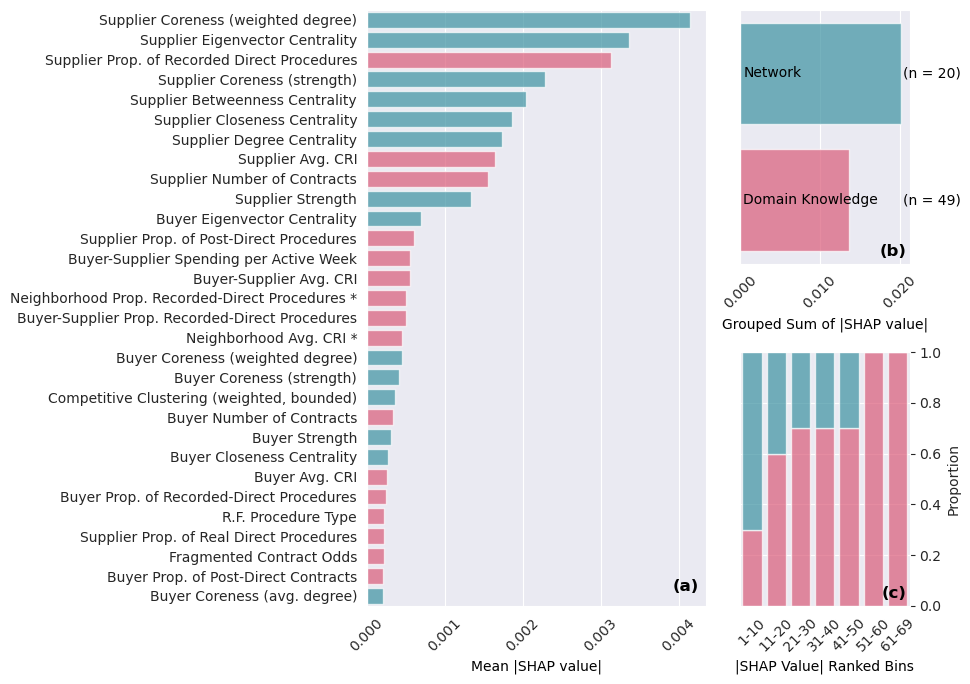

In [4]:
#########################
# Feature importance
#########################


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Helper function to add subplot labels
def label_subplot(ax, label):
    ax.text(
        0.98, 0.02, label,
        transform=ax.transAxes,
        ha='right', va='bottom',
        fontsize=12, fontweight='bold',
        color='black'
    )

# Set seaborn style to darkgrid
sns.set_style("darkgrid")

# Define consistent colors
# level_order = [
#     'Bipartite Network', 
#     'Domain Knowledge', 
#     #'Network Embedding',
#     'Supplier Projection',
#     'Buyer Projection'
#     ]
level_order = [
    'Domain Knowledge', 
    'Network'
]

my_palette2 = [
    #'#44af69', # green
    '#ef476f', # red
    #'#fcab10', # yellow
    '#2b9eb3', # blue
    '#B8B8FF',
]
color_map = dict(zip(level_order, my_palette2))

# Create figure with GridSpec
fig = plt.figure(figsize=(10, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[2, 1])

# ========== PLOT 1: Top 30 SHAP values ==========
ax1 = fig.add_subplot(gs[:, 0])
top_k_features = 30
df2plot_global = shap_values_values.head(top_k_features).copy()
df2plot_global['column'] = df2plot_global['column'].replace({
    'Neighborhood Avg. CRI': 'Neighborhood Avg. CRI *',
    'Neighborhood Prop. Recorded-Direct Procedures': 'Neighborhood Prop. Recorded-Direct Procedures *'
})

# Use the 'level' column to color bars
bar_colors = df2plot_global['level'].map(color_map)

sns.barplot(
    x='average', 
    y='column', 
    data=df2plot_global, 
    orient='h', 
    palette=bar_colors,  
    ax=ax1,
    alpha=0.7
)

ax1.set_xlabel('Mean |SHAP value|', color='black')
ax1.set_ylabel('', color='black')
ax1.tick_params(axis='x', rotation=45)
label_subplot(ax1, '(a)')

# ========== PLOT 2: Grouped feature type ==========

ax2 = fig.add_subplot(gs[0, 1])

# ---- 1. Compute grouped SHAP values ----
groupped_feature_type = (
    shap_values_values
    .groupby('level')
    .sum()
    .sort_values('average', ascending=False)
    .reset_index()
)

# ---- 2. Count number of features per level ----
counts = shap_values_values.groupby('level').size()

# ---- 3. Store name and count separately ----
groupped_feature_type['name'] = groupped_feature_type['level']
groupped_feature_type['n'] = groupped_feature_type['level'].map(counts)

# ---- 4. Plot with name column (we will draw n manually) ----
sns.barplot(
    x='average', 
    y='name', 
    data=groupped_feature_type, 
    orient='h',
    palette=[color_map[l] for l in groupped_feature_type['level']], 
    ax=ax2,
    alpha=0.7
)

# ---- 5. Remove y-axis ticks and labels because we draw manually ----
ax2.set_yticks([])

# ---- 6. Manual text drawing: left = name, right = aligned n ----
ax2.set_xlabel('Grouped Sum of |SHAP value|', color='black')

# Compute positions
x_min, x_max = ax2.get_xlim()

name_x = x_min + 0.02 * (x_max - x_min)  # left-aligned text
n_x    = x_min + 1.3 * (x_max - x_min)  # **right-aligned n column** (adjust as needed)

for i, row in groupped_feature_type.iterrows():
    # Left = feature name
    ax2.text(name_x, i, row['name'], va='center', ha='left', color='black')

    # Right = aligned n column
    ax2.text(n_x, i, f"(n = {row['n']})",
             va='center', ha='right', color='black')

# ---- 7. Styling ----
ax2.set_ylabel('')
if ax2.get_legend():
    ax2.legend_.remove()

ax2.tick_params(axis='x', rotation=45)
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.3f}"))

label_subplot(ax2, '(b)')

# ========== PLOT 3: Proportion of levels by ranking bins ==========
ax3 = fig.add_subplot(gs[1, 1])
df2plot = shap_values_values.copy()
#df2plot = df2plot.sort_values(by = 'average', ascending=False).reset_index(drop=True)
# shap_values_dict = shap_values_values.set_index('column').to_dict()['average']
# df2plot = colnames_correspondence.reset_index(drop=True)
# colnames_correspondence['average'] = colnames_correspondence['name'].map(shap_values_dict)
df2plot = df2plot.dropna(subset=['average']).sort_values('average', ascending=False).reset_index(drop=True)
bin_size = 10
df2plot['RankBin'] = df2plot.index // bin_size + 1
df2plot['RankBinLabel'] = df2plot['RankBin'].apply(lambda x: f"{(x-1)*bin_size + 1}-{min(x*bin_size, len(df2plot))}")
df2plot = df2plot.groupby(['RankBin', 'RankBinLabel', 'level']).size().reset_index(name='Count')
df2plot['Total'] = df2plot.groupby('RankBin')['Count'].transform('sum')
df2plot['Proportion'] = df2plot['Count'] / df2plot['Total']
bins_correspondence = df2plot.set_index('RankBin').to_dict()['RankBinLabel']

df2plot_pivot = df2plot.pivot(index=['RankBin', 'RankBinLabel'], columns='level', values='Proportion').fillna(0).reset_index()

bottom_values = [0] * len(df2plot_pivot)
for level in level_order:
    if level in df2plot_pivot.columns:
        sns.barplot(
            x='RankBinLabel',
            y=level,
            data=df2plot_pivot,
            color=color_map[level],
            ax=ax3,
            bottom=bottom_values,
            alpha=0.7
        )
        bottom_values = [b + v for b, v in zip(bottom_values, df2plot_pivot[level])]

ax3.set_ylabel("Proportion")
ax3.set_xlabel("|SHAP Value| Ranked Bins", color='black')
ax3.tick_params(axis='x', rotation=45)

if ax3.get_legend():
    ax3.legend_.remove()

ax3.yaxis.tick_right()
ax3.yaxis.set_label_position("right")
label_subplot(ax3, '(c)')

plt.tight_layout()
#filename = f'general_shapvalues_top{top_k_features}.png'
#plt.savefig(figures_folder / filename, bbox_inches='tight', dpi=300, facecolor='white')
plt.show()


In [5]:
# Feature importance transductive vs inductive

shap_data_inductive = here('data/processed_data/inductive_data/shap_values/')

#load shap values of EPN
with open(shap_data_inductive / 'SHAP_EPN_hdsrf_param1113_testtype_YSFull_rs42.pickle', 'rb') as f:
    shap_values_EPN = pickle.load(f)
shap_values_EPN.feature_names = list(pd.Series(X_test_names_CSFull.columns).map(colnames_correspondence_dict))
#load shap values of AMLO
with open(shap_data_inductive / 'SHAP_EPN_hdsrf_param1113_testtype_YSFull_rs42.pickle', 'rb') as f:
    shap_values_AMLO = pickle.load(f)
shap_values_AMLO.feature_names = list(pd.Series(X_test_names_CSFull.columns).map(colnames_correspondence_dict))
#load shap values Transductive
with open(shap_data / 'SHAP_hdsrf_param9993_testtype_CSFull_rs42.pickle', 'rb') as f:
    shap_values_transductive = pickle.load(f)
shap_values_transductive.feature_names = list(pd.Series(X_test_names_CSFull.columns).map(colnames_correspondence_dict))

#process the data
k = 30
top_features_transductive = get_top_features(shap_values_transductive, k)
top_features_EPN = get_top_features(shap_values_EPN, k)
top_features_AMLO = get_top_features(shap_values_AMLO, k)

all_top_features = []
all_top_features = top_features_transductive.copy()
for i in top_features_AMLO:
    for j in top_features_EPN:
        if j not in all_top_features:
            all_top_features.append(j)
    if i not in all_top_features:
        all_top_features.append(i)

all_top_features = all_top_features[::-1]
print(all_top_features)



['Buyer-Supplier Num. Contracts Odds', 'Buyer-Supplier Num. Contracts', 'Buyer-supplier active weeks', 'Goods', 'R.F. Buyer Dependence', 'Supplier Coreness (avg. degree)', 'Supplier Size', 'Buyer Coreness (avg. degree)', 'Buyer Prop. of Post-Direct Contracts', 'Fragmented Contract Odds', 'Supplier Prop. of Real Direct Procedures', 'R.F. Procedure Type', 'Buyer Prop. of Recorded-Direct Procedures', 'Buyer Avg. CRI', 'Buyer Closeness Centrality', 'Buyer Strength', 'Buyer Number of Contracts', 'Competitive Clustering (weighted, bounded)', 'Buyer Coreness (strength)', 'Buyer Coreness (weighted degree)', 'Neighborhood Avg. CRI', 'Buyer-Supplier Prop. Recorded-Direct Procedures', 'Neighborhood Prop. Recorded-Direct Procedures', 'Buyer-Supplier Avg. CRI', 'Buyer-Supplier Spending per Active Week', 'Supplier Prop. of Post-Direct Procedures', 'Buyer Eigenvector Centrality', 'Supplier Strength', 'Supplier Number of Contracts', 'Supplier Avg. CRI', 'Supplier Degree Centrality', 'Supplier Closenes

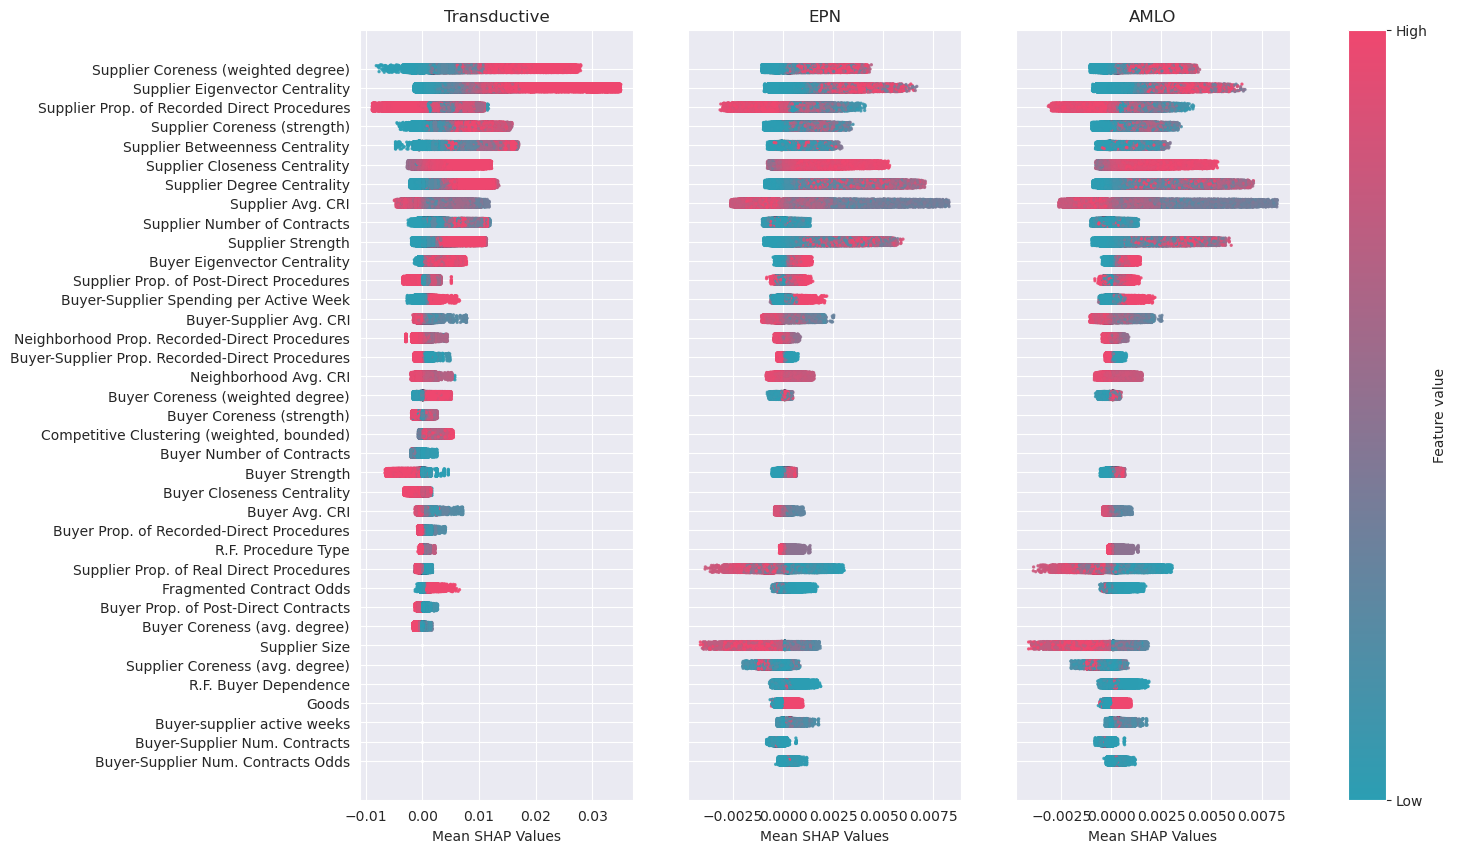

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
from matplotlib.colors import Normalize 
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap

blue = '#2b9eb3'
red = '#ef476f'
custom_cmap = LinearSegmentedColormap.from_list("blue_red_cmap", [blue, red])

figs, axs = plt.subplots(1, 3, figsize=(15, 10), sharey=True)

for idx, (ax, admin) in enumerate(zip(axs.flatten(), ['Transductive', 'EPN', 'AMLO'])):
    if admin == 'Transductive':
        shap_values_sub = shap_values_transductive
        cols2keep = top_features_transductive
    elif admin == 'EPN':
        shap_values_sub = shap_values_EPN
        cols2keep = top_features_EPN
    elif admin == 'AMLO':
        shap_values_sub = shap_values_AMLO
        cols2keep = top_features_AMLO

    df2plot = pd.DataFrame(shap_values_sub[:, :].values)
    df2plot.columns = list(pd.Series(X_test_names_CSFull.columns).map(colnames_correspondence_dict))
    #df2plot = df2plot[cols2keep]

    df4colors = pd.DataFrame(shap_values_sub[:, :].data)
    df4colors.columns = list(pd.Series(X_test_names_CSFull.columns).map(colnames_correspondence_dict))
    #df4colors = df4colors[cols2keep]

    cmap = custom_cmap  

    for i, col in enumerate(all_top_features):
        vals = df2plot[col].values
        colors_vals = df4colors[col].values
        low, high = colors_vals.min(), np.quantile(colors_vals, 0.95)

        norm = Normalize(vmin=low, vmax=high, clip=True)
        colors = cmap(norm(colors_vals))

        y_jitter = np.random.uniform(-0.2, 0.2, size=len(vals))
        y_positions = np.full(len(vals), i) + y_jitter

        if col in cols2keep:
            ax.scatter(
                x=vals, 
                y=y_positions, 
                c=colors,
                s=2,
                alpha=0.8,
            )
        else:
            ax.scatter(
                x=[0], 
                y=[i], 
                c='white',
                s=2,
                alpha=0.8,
            )

    # Fix ticks and labels
    ax.set_yticks(range(len(all_top_features)))
    ax.set_yticklabels(all_top_features)

    ax.set_xlabel("Mean SHAP Values")
    
    ax.set_title(f"{admin}")

# Shared colorbar
sm = ScalarMappable(cmap=cmap, norm=Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = figs.colorbar(sm, ax=axs, orientation="vertical", label="Feature value")
# Customize the colorbar ticks and labels
cbar.set_ticks([0, 1])  # Set ticks only at the extremes
cbar.set_ticklabels(['Low', 'High'])  # Set custom labels

#filename = f'YSComparison_shap_values_top_{k}_features.png'
#figures_folder = here() / 'figures' / 'shap_figures'
#plt.savefig(figures_folder / filename, bbox_inches='tight', dpi=300, facecolor='white')
plt.show()

# SHAP dependence plots

In [7]:
#top 10 features
top10features = set(shap_values_values['column'].head(10))
#top 20 features
top20features = set(shap_values_values['column'].head(20))
top20features = top20features.difference(top10features)
#top 30 features
top30features = set(shap_values_values['column'].head(30))
top30features = top30features.difference(top10features)
top30features = top30features.difference(top20features)

#Dict with values * for top10, ** for top20, *** for top30
shap_values_values['stars'] = ''
shap_values_values.loc[shap_values_values['column'].isin(top10features), 'stars'] = '*'
shap_values_values.loc[shap_values_values['column'].isin(top20features), 'stars'] = '**'
shap_values_values.loc[shap_values_values['column'].isin(top30features), 'stars'] = '***'
stars_dict = shap_values_values.set_index('column').to_dict()['stars']


In [8]:
X_test_names_CSFull.rename(columns=colnames_correspondence_dict, inplace=True)

all_shap = shap_values.values
print(all_shap.shape, all_shap.shape[0]*all_shap.shape[1])
all_shap = all_shap.flatten()
shap_threshold_pos= np.quantile(all_shap, 0.90)
shap_threshold_neg=  np.quantile(all_shap, 0.10)


conditions = [
    (X_test_names_CSFull['R.F. Procedure Type'] != 1),
    ((X_test_names_CSFull['R.F. Procedure Type'] == 1) & (X_test_names_CSFull['R.F. Submission Period'] != 1)), #Post-Direct
    ((X_test_names_CSFull['R.F. Procedure Type'] == 1) & (X_test_names_CSFull['R.F. Submission Period'] == 1)), #Real-Direct 
    ]

choices = [0, 0.5, 1]


X_test_names_CSFull['Procedure Type'] = np.select(conditions, choices, default=-1)

(460172, 69) 31751868


Supplier Coreness (weighted degree)
Buyer Coreness (weighted degree)
Supplier Eigenvector Centrality
Buyer Eigenvector Centrality
Supplier Closeness Centrality
Buyer Closeness Centrality
Supplier Degree Centrality
Buyer Degree Centrality


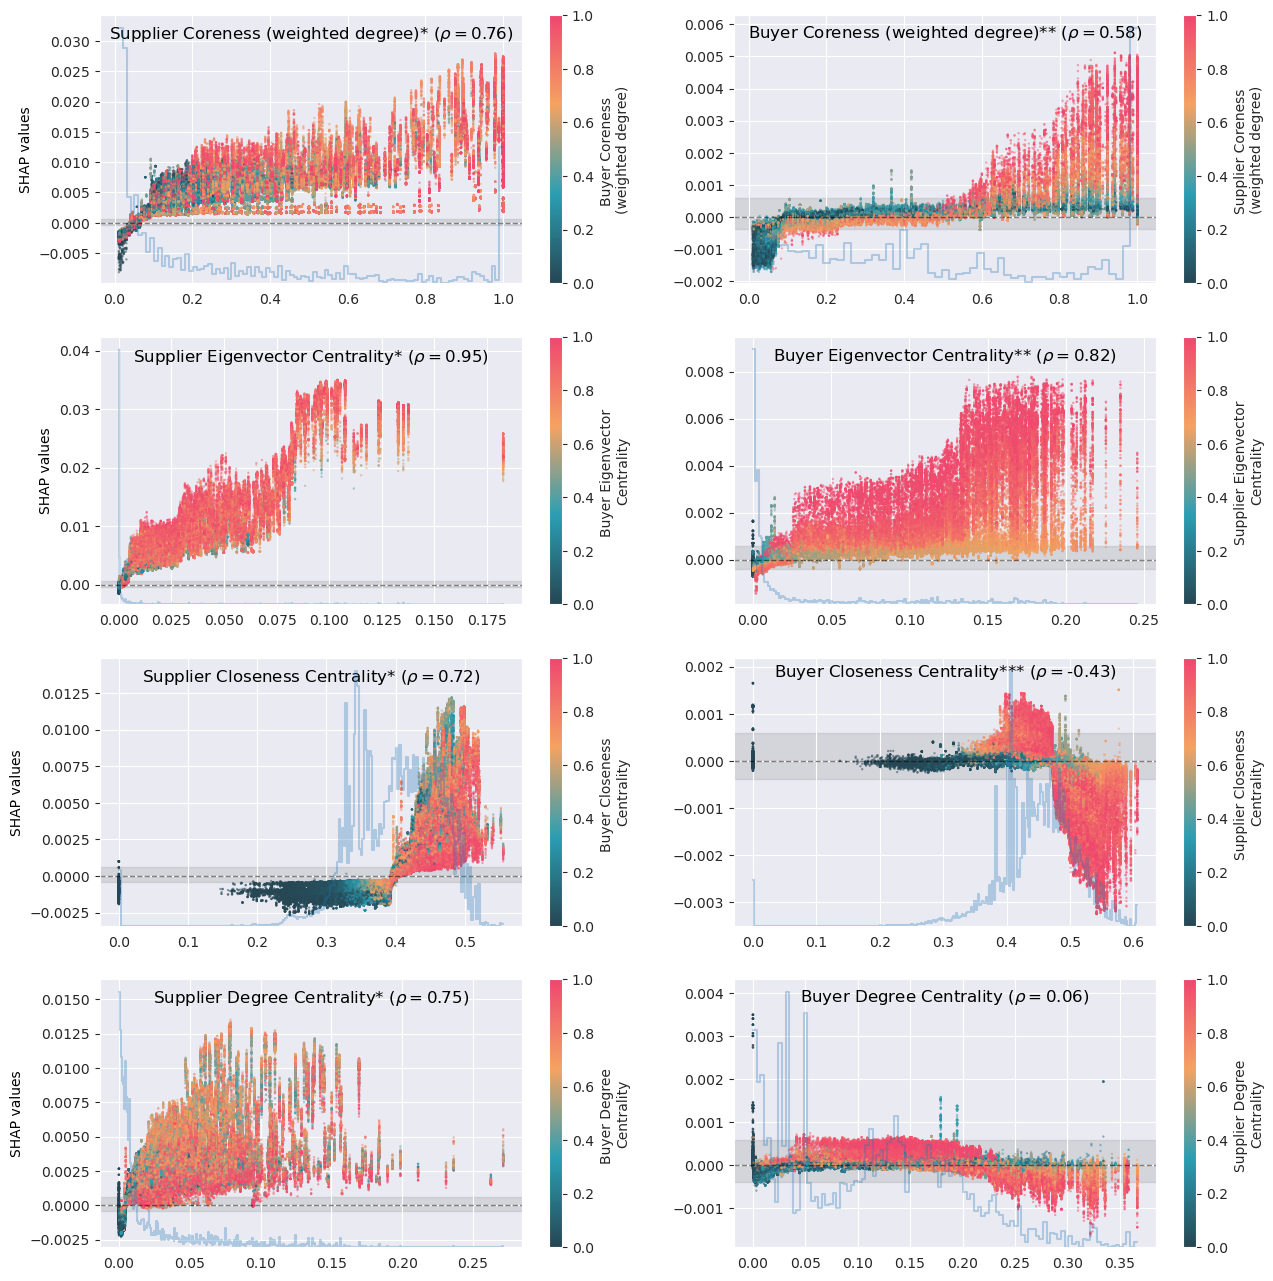

In [9]:

######################### NETWORK
grouping_plot = 'NETWORK_orgscale'

centrality_var_list = [
 {'Supplier Coreness (weighted degree)': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Buyer Coreness (weighted degree)',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 0,
   'out': False}},
 {'Buyer Coreness (weighted degree)': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Supplier Coreness (weighted degree)',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 0,
   'out': False}},
 {'Supplier Eigenvector Centrality': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Buyer Eigenvector Centrality',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 1,
   'out': False}},
 {'Buyer Eigenvector Centrality': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Supplier Eigenvector Centrality',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 1,
   'out': False}},
 {'Supplier Closeness Centrality': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Buyer Closeness Centrality',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 2,
   'out': False}},
 {'Buyer Closeness Centrality': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Supplier Closeness Centrality',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 2,
   'out': False}},
 {'Supplier Degree Centrality': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Buyer Degree Centrality',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 3,
   'out': False}},
 {'Buyer Degree Centrality': {'x_type': 'continuous',
   'x_scale_correction': {'None': None},
   'x_values': None,
   'x_jitter': None,
   'x_lims': None,
   'interaction_var': 'Supplier Degree Centrality',
   'interaction_type': 'continuous',
   'interaction_scale_correction': {'quantile': 1000},
   'interaction_values': None,
   'position_idx': 3,
   'out': False}},

   ]

#################################################


from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize 
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy import stats

nrows = 4
ncols = 2
fig_long = 16
fig_wide = 15

grouping_plot = 'NETWORK_orgscale'
var_list = centrality_var_list.copy()

#################################################

#palette
lower_blue = '#264653'
blue = '#2b9eb3'
orange = '#F4A261'
red = '#ef476f'
custom_cmap = LinearSegmentedColormap.from_list("blue_red_cmap", [lower_blue, blue, orange , red])
norm = Normalize(vmin=0, vmax=1)
sm = ScalarMappable(norm=norm, cmap=custom_cmap)
fontsize = 9


# Create a figure with subplots
fig, axs = plt.subplots(
    nrows, 
    ncols, 
    figsize=(fig_wide, fig_long), 
    sharey=False, 
    sharex=False)

fig.patch.set_facecolor('white')  # Set the background color

for idx, (ax, var_dict) in enumerate(zip(axs.flatten(), var_list)):

    column2plot = list(var_dict.keys())[0]
    interaction_var = var_dict[column2plot]['interaction_var']
    print(column2plot)
    x = X_test_names_CSFull[column2plot].values
    n = len(x)
    # Create dataframe for current column
    
    if interaction_var is None:
        interaction_var = column2plot  #if no interaction var, use the same variable (will not be used)

    df2plot = pd.DataFrame({
        'x': x,
        'y': shap_values[:, column2plot].values,
        'color' : X_test_names_CSFull[interaction_var].values
    })
    df2plot_dist = df2plot.copy()

    #variable type
    vartype = var_dict[column2plot]['x_type']
    interactiontype = var_dict[column2plot]['interaction_type']
    
    #THIS IS FOR X SCALE CORRECTION
    key_x = next(iter(var_dict[column2plot]['x_scale_correction'])) #get the key
    
    if key_x == 'quantile':
        scale_correction = var_dict[column2plot]['x_scale_correction']['quantile']
        df2plot['x'] = pd.qcut(df2plot['x'].rank(method='first'), scale_correction, labels=False) + 1
        df2plot['x'] = df2plot['x'] / scale_correction
    elif key_x == 'x_cutoff':
        x_min_ = np.round(df2plot['x'].min(), 2)
        x_max_ = np.round(df2plot['x'].max(), 2)
        x_cutoff = var_dict[column2plot]['x_scale_correction']['x_cutoff']
        low_label = f'''[{x_min_}, {x_cutoff}]'''
        high_label = f'''({x_cutoff}, {x_max_}]'''
        df2plot['x'] = np.where(df2plot['x'] <= x_cutoff, low_label, high_label)
        df2plot['x'] = pd.Categorical(df2plot['x'], categories=[low_label, high_label], ordered=True)
    ##################################################################
    elif key_x == 'bottom-top':
        threshold_q = var_dict[column2plot]['x_scale_correction']['bottom-top']
        low_label = 'Bottom-' + str(int(threshold_q*100))
        high_label = 'Top-' + str(int(round(1-threshold_q, 1)*100))
        df2plot['x'] = np.where(df2plot['x'] < df2plot['x'].quantile(threshold_q), low_label, high_label)
        df2plot['x'] = pd.Categorical(df2plot['x'], categories=[low_label, high_label], ordered=True)
    elif key_x == 'notation':
        notation_base = var_dict[column2plot]['x_scale_correction']['notation']
        df2plot['x'] = df2plot['x'] * (10**notation_base)
        df2plot_dist = df2plot.copy()
    elif key_x == 'log':
        df2plot['x'] = np.log(df2plot['x'])
        df2plot_dist = df2plot.copy()
    elif key_x == 'categorical':
        new_vals = var_dict[column2plot]['x_scale_correction']['categorical']
        unique_vals = sorted(df2plot['x'].unique())
        replace_vals = dict(zip(unique_vals, new_vals))
        print(replace_vals)
        df2plot['x'] = df2plot['x'].map(replace_vals)
        df2plot['x'] = pd.Categorical(df2plot['x'] , categories=new_vals, ordered=True)
    elif key_x == 'None':
        df2plot['x'] = df2plot['x']
    else:
        break
    #THIS IS FOR INTERACTION VARIABLE
    key_interaction = next(iter(var_dict[column2plot]['interaction_scale_correction'])) #get the key
    
    if key_interaction == 'categorical':
        new_vals = var_dict[column2plot]['interaction_scale_correction']['categorical']
        unique_vals = sorted(df2plot['color'].unique())
        replace_vals = dict(zip(unique_vals, new_vals))
        print(replace_vals)
        df2plot['color'] = df2plot['color'].map(replace_vals)
        df2plot['color'] = pd.Categorical(df2plot['color'] , categories=new_vals, ordered=True)

    elif key_interaction == 'quantile':
        scale_correction = var_dict[column2plot]['interaction_scale_correction']['quantile']
        df2plot['color'] = pd.qcut(df2plot['color'].rank(method='first'), scale_correction, labels=False) + 1
        df2plot['color'] = df2plot['color'] / scale_correction
    elif key_interaction == 'None':
        print('worked')
        #df2plot['color'] = df2plot['color']
    else:
        break
    #######################################            
    ########## PLOTS ######################
    #######################################

    # ========== SHAP = 0 =========================
    ax.axhline(
        0, 
        color='black', 
        linestyle='--', 
        linewidth=1, 
        alpha=0.5
        )

  
    #=========== Scatter plot =====================

    #scatter plot
    if vartype in ['continuous']:
        if interactiontype == 'categorical':
            palette_dict = dict(zip(new_vals, [blue, orange, red]))
            ax.scatter(
                x = df2plot['x'],
                y = df2plot['y'],
                c = df2plot['color'].map(palette_dict),
                linewidth = 0,
                s = 3,
                alpha = 0.5)
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', label=str(label),
                markerfacecolor=color, markersize=8) for label, color in palette_dict.items()
            ]

            ax.legend(
                handles=legend_elements,
                title='Procedure Type',
                #bbox_to_anchor=(1.05, 0.8),
                loc='upper right',
                frameon=False,
                fontsize = fontsize
            )
        elif interactiontype == 'continuous':
            ax.scatter(
                x = df2plot['x'],
                y = df2plot['y'],
                c = df2plot['color'],
                cmap = custom_cmap,
                linewidth = 0,
                s = 3,
                alpha = 0.5)

        else:
            ax.scatter(
                x = df2plot['x'],
                y = df2plot['y'],
                c = blue,
                linewidth = 0,
                s = 3,
                alpha = 0.5)
    
    xlim = ax.get_xlim()
            
    if column2plot == 'Supplier Prop. of Recorded Direct Procedures':
        for t in [0.5, 0.9]:
            ax.axvline(x=t, 
                       linestyle='--', 
                       linewidth=1,
                       color = 'grey')  
            rho_t = stats.pearsonr(df2plot[df2plot['x'] < t]['x'],
                                   df2plot[df2plot['x'] < t]['y'])[0]
            rho_t = np.round(rho_t, 2)
            rho_text = f'''for x <{t}: \n''' + r"$\rho = $" + f'{rho_t}'
            ax.text(
                x=(xlim[0] + t - 0.05),     # center horizontally
                y= -0.005, #ylim[1]*0.05,                     # top of y-axis
                s=rho_text,
                ha='center',
                va='top',                      # align top of text with y=ylim[1]
                fontsize=fontsize,
                color='black',
                transform=ax.transData,        # position in data coordinates
                zorder=10,
            )
    if column2plot == 'Supplier Avg. CRI':
        for t in [0.5]:
            ax.axvline(x=t, 
                    linestyle='--', 
                    linewidth=1,
                    color = 'grey')  
            rho_t = stats.pearsonr(df2plot[df2plot['x'] < t]['x'],
                                df2plot[df2plot['x'] < t]['y'])[0]
            rho_t = np.round(rho_t, 2)
            rho_text = f'''for x <{t}: \n''' + r"$\rho = $" + f'{rho_t}' +f''' \n(78% of non-direct)'''
            ax.text(
                x=(xlim[0] + 0.25),     # center horizontally
                y= -0.001, #ylim[1]*0.05,                     # top of y-axis
                s=rho_text,
                ha='center',
                va='top',                      # align top of text with y=ylim[1]
                fontsize=fontsize,
                color='black',
                transform=ax.transData,        # position in data coordinates
                zorder=10,
            )
            rho_t = stats.pearsonr(df2plot[df2plot['x'] >= t]['x'],
                                df2plot[df2plot['x'] >= t]['y'])[0]
            rho_t = np.round(rho_t, 2)
            rho_text = f'''for x >= {t}: \n''' + r"$\rho = $" + f'{rho_t}' +f''' \n(93% of real-direct)'''
            ax.text(
                x=(xlim[0] + t + 0.3),     # center horizontally
                y= 0.005, #ylim[1]*0.05,                     # top of y-axis
                s=rho_text,
                ha='center',
                va='top',                      # align top of text with y=ylim[1]
                fontsize=fontsize,
                color='black',
                transform=ax.transData,        # position in data coordinates
                zorder=10,
            )

 
    #=========== Box plot =====================
    if vartype in ['categorical']:

        sns.boxplot(
                    #hue = df2plot['color'],
                    y = df2plot['y'],
                    x = df2plot['x'],
                    color=blue,
                    #palette=palette_dict,
                    showmeans = True,
                    meanprops={"marker":"o",
                            "markerfacecolor":"white", 
                            "markeredgecolor":"black",
                            "markersize":"5"},
                    ax=ax
                )
        #ax.legend_.remove()

    if key_x in ['None', 'log', 'notation']:
           
        ax2 = ax.twinx()

        sns.histplot(
                data = df2plot_dist, 
                x='x', 
                alpha=0.3, 
                ax=ax2,
                fill=False,
                kde=False,
                element='step',
                )
        
        ax2.yaxis.set_visible(False)
        ax2.xaxis.set_visible(False)

    # ========== Mark 80% of SHAP values ==========
    xmin, xmax = ax.get_xlim()

    # After creating the boxplot:

    # after your sns.boxplot(...)
    ax.axhspan(
        shap_threshold_neg,          # lower y bound
        shap_threshold_pos,          # upper y bound
        color='grey',
        alpha=0.2,
        zorder=0     # keep it behind the boxplot
    )


    #=========== Set Interaction labels =====================

    #remove 'Centrality', '(weighted degree)'
    interaction_name = interaction_var.replace('Centrality', '\nCentrality').strip()
    interaction_name = interaction_name.replace('(weighted degree)', '\n(weighted degree)').strip()
    #add \n after 'Recorded'"
    interaction_name = interaction_name.replace('Recorded', 'Recorded\n')

    #=========== Colorbar ===================================
    
    if interactiontype == 'continuous':
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(interaction_name)

    # ========== Set limits =================================
    # Get current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.set_ylim(ylim[0], ylim[1] * 1.15)



    #=========== Set X labels =====================
    #ax.set_xlabel(column2plot + stars_dict[column2plot], color='black')
    label_text = column2plot + stars_dict[column2plot]
    pear_corr = stats.pearsonr(df2plot['x'], df2plot['y'])
    pear_corr = np.round(pear_corr[0],2)

    if key_x == 'log':
        label_text = label_text + ' (log)'
    
    if column2plot == 'Buyer-Supplier Spending per Active Week':
        label_text = label_text + f' \n(' + r"$\rho = $" + f'{pear_corr})'    
    
    else:
        label_text = label_text + ' (' + r"$\rho = $" + f'{pear_corr})'


    ax.text(
        x=(xlim[0] + xlim[1]) / 2,     # center horizontally
        y=ylim[1]*1.1,                     # top of y-axis
        s=label_text,
        ha='center',
        va='top',                      # align top of text with y=ylim[1]
        fontsize=12,
        color='black',
        transform=ax.transData,        # position in data coordinates
        zorder=10,
    )

    # Optional: Remove default xlabel and top ticks
    ax.set_xlabel('')
    #ax.tick_params(labeltop=False, top=False)


    #=========== Set Y labels =====================    
    ylabtrue = idx%ncols == 0
    if ylabtrue:
        ax.set_ylabel('SHAP values', color='black')
    else:
        ax.set_ylabel('')
    


#Save the figure
#filename = 'shap_dependence_' + grouping_plot +'.png'
#plt.savefig(figures_folder / filename, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


Supplier Avg. CRI


{0.0: 'Non-Direct', 0.5: 'Post-Direct', 1.0: 'Real-Direct'}
Supplier Prop. of Recorded Direct Procedures
worked
Supplier Number of Contracts
Buyer-Supplier Spending per Active Week


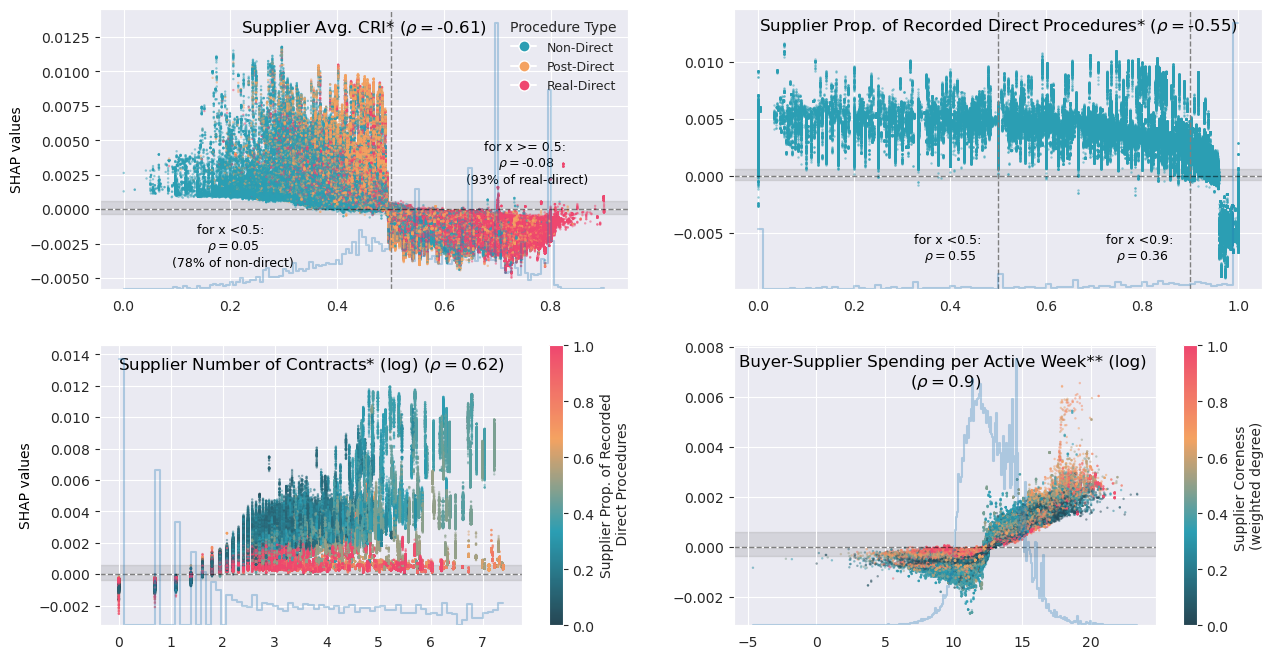

In [10]:

######################### NETWORK
grouping_plot = 'NETWORK_orgscale'

dom_knowledge_orgscale = [
    {           
    'Supplier Avg. CRI': {
        'x_type': 'continuous',
        'x_scale_correction': {'None': None},
        'x_values': None,
        'x_jitter': None,
        'x_lims' : None,
        'interaction_var': 'Procedure Type',
        'interaction_type': 'categorical',
        'interaction_scale_correction': {'categorical': ['Non-Direct', 'Post-Direct', 'Real-Direct'] },
        'position_idx': 1,
        'out': False
    }},
    {
    'Supplier Prop. of Recorded Direct Procedures': {
        'x_type': 'continuous', 
        'x_scale_correction': {'None': None }, 
        'x_values': None,
        'x_jitter': None,
        'x_lims' : None,
        'interaction_var': None,
        'interaction_type': {'None': None },
        'interaction_scale_correction': {'None': None },
        #'interaction_values': None,
        'position_idx': 2,
        'out': False    
    }},
    {
        'Supplier Number of Contracts': {
        'x_type': 'continuous',
        'x_scale_correction': {'log' : '(log scale)'},
        'x_values': None,
        'x_jitter': None,
        'x_lims' : None,
        'interaction_var': 'Supplier Prop. of Recorded Direct Procedures',
        'interaction_type': 'continuous',
        'interaction_scale_correction': {'quantile': 1000},
        'interaction_values': None,
        'position_idx': 4,
        'out': False}
    } ,
    {
        'Buyer-Supplier Spending per Active Week': {
        'x_type': 'continuous',
        'x_scale_correction': {'log' : '(log scale)'},
        'x_values': None,
        'x_jitter': None,
        'x_lims' : None,
        'interaction_var': 'Supplier Coreness (weighted degree)',
        'interaction_type': 'continuous',
        'interaction_scale_correction': {'quantile': 1000},
        'interaction_values': None,
        'position_idx': 5,
        'out': False}
    }
   ]

#################################################


from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize 
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy import stats

nrows = 2
ncols = 2
fig_long = 8
fig_wide = 15

grouping_plot = 'DOMAIN_KNOWLEDGE_orgscale'
var_list = dom_knowledge_orgscale.copy()

#################################################

#palette
lower_blue = '#264653'
blue = '#2b9eb3'
orange = '#F4A261'
red = '#ef476f'
custom_cmap = LinearSegmentedColormap.from_list("blue_red_cmap", [lower_blue, blue, orange , red])
norm = Normalize(vmin=0, vmax=1)
sm = ScalarMappable(norm=norm, cmap=custom_cmap)
fontsize = 9


# Create a figure with subplots
fig, axs = plt.subplots(
    nrows, 
    ncols, 
    figsize=(fig_wide, fig_long), 
    sharey=False, 
    sharex=False)

fig.patch.set_facecolor('white')  # Set the background color

for idx, (ax, var_dict) in enumerate(zip(axs.flatten(), var_list)):

    column2plot = list(var_dict.keys())[0]
    interaction_var = var_dict[column2plot]['interaction_var']
    print(column2plot)
    x = X_test_names_CSFull[column2plot].values
    n = len(x)
    # Create dataframe for current column
    
    if interaction_var is None:
        interaction_var = column2plot  #if no interaction var, use the same variable (will not be used)

    df2plot = pd.DataFrame({
        'x': x,
        'y': shap_values[:, column2plot].values,
        'color' : X_test_names_CSFull[interaction_var].values
    })
    df2plot_dist = df2plot.copy()

    #variable type
    vartype = var_dict[column2plot]['x_type']
    interactiontype = var_dict[column2plot]['interaction_type']
    
    #THIS IS FOR X SCALE CORRECTION
    key_x = next(iter(var_dict[column2plot]['x_scale_correction'])) #get the key
    
    if key_x == 'quantile':
        scale_correction = var_dict[column2plot]['x_scale_correction']['quantile']
        df2plot['x'] = pd.qcut(df2plot['x'].rank(method='first'), scale_correction, labels=False) + 1
        df2plot['x'] = df2plot['x'] / scale_correction
    elif key_x == 'x_cutoff':
        x_min_ = np.round(df2plot['x'].min(), 2)
        x_max_ = np.round(df2plot['x'].max(), 2)
        x_cutoff = var_dict[column2plot]['x_scale_correction']['x_cutoff']
        low_label = f'''[{x_min_}, {x_cutoff}]'''
        high_label = f'''({x_cutoff}, {x_max_}]'''
        df2plot['x'] = np.where(df2plot['x'] <= x_cutoff, low_label, high_label)
        df2plot['x'] = pd.Categorical(df2plot['x'], categories=[low_label, high_label], ordered=True)
    ##################################################################
    elif key_x == 'bottom-top':
        threshold_q = var_dict[column2plot]['x_scale_correction']['bottom-top']
        low_label = 'Bottom-' + str(int(threshold_q*100))
        high_label = 'Top-' + str(int(round(1-threshold_q, 1)*100))
        df2plot['x'] = np.where(df2plot['x'] < df2plot['x'].quantile(threshold_q), low_label, high_label)
        df2plot['x'] = pd.Categorical(df2plot['x'], categories=[low_label, high_label], ordered=True)
    elif key_x == 'notation':
        notation_base = var_dict[column2plot]['x_scale_correction']['notation']
        df2plot['x'] = df2plot['x'] * (10**notation_base)
        df2plot_dist = df2plot.copy()
    elif key_x == 'log':
        df2plot['x'] = np.log(df2plot['x'])
        df2plot_dist = df2plot.copy()
    elif key_x == 'categorical':
        new_vals = var_dict[column2plot]['x_scale_correction']['categorical']
        unique_vals = sorted(df2plot['x'].unique())
        replace_vals = dict(zip(unique_vals, new_vals))
        print(replace_vals)
        df2plot['x'] = df2plot['x'].map(replace_vals)
        df2plot['x'] = pd.Categorical(df2plot['x'] , categories=new_vals, ordered=True)
    elif key_x == 'None':
        df2plot['x'] = df2plot['x']
    else:
        break
    #THIS IS FOR INTERACTION VARIABLE
    key_interaction = next(iter(var_dict[column2plot]['interaction_scale_correction'])) #get the key
    
    if key_interaction == 'categorical':
        new_vals = var_dict[column2plot]['interaction_scale_correction']['categorical']
        unique_vals = sorted(df2plot['color'].unique())
        replace_vals = dict(zip(unique_vals, new_vals))
        print(replace_vals)
        df2plot['color'] = df2plot['color'].map(replace_vals)
        df2plot['color'] = pd.Categorical(df2plot['color'] , categories=new_vals, ordered=True)

    elif key_interaction == 'quantile':
        scale_correction = var_dict[column2plot]['interaction_scale_correction']['quantile']
        df2plot['color'] = pd.qcut(df2plot['color'].rank(method='first'), scale_correction, labels=False) + 1
        df2plot['color'] = df2plot['color'] / scale_correction
    elif key_interaction == 'None':
        print('worked')
        #df2plot['color'] = df2plot['color']
    else:
        break
    #######################################            
    ########## PLOTS ######################
    #######################################

    # ========== SHAP = 0 =========================
    ax.axhline(
        0, 
        color='black', 
        linestyle='--', 
        linewidth=1, 
        alpha=0.5
        )

  
    #=========== Scatter plot =====================

    #scatter plot
    if vartype in ['continuous']:
        if interactiontype == 'categorical':
            palette_dict = dict(zip(new_vals, [blue, orange, red]))
            ax.scatter(
                x = df2plot['x'],
                y = df2plot['y'],
                c = df2plot['color'].map(palette_dict),
                linewidth = 0,
                s = 3,
                alpha = 0.5)
            legend_elements = [
                Line2D([0], [0], marker='o', color='w', label=str(label),
                markerfacecolor=color, markersize=8) for label, color in palette_dict.items()
            ]

            ax.legend(
                handles=legend_elements,
                title='Procedure Type',
                #bbox_to_anchor=(1.05, 0.8),
                loc='upper right',
                frameon=False,
                fontsize = fontsize
            )
        elif interactiontype == 'continuous':
            ax.scatter(
                x = df2plot['x'],
                y = df2plot['y'],
                c = df2plot['color'],
                cmap = custom_cmap,
                linewidth = 0,
                s = 3,
                alpha = 0.5)

        else:
            ax.scatter(
                x = df2plot['x'],
                y = df2plot['y'],
                c = blue,
                linewidth = 0,
                s = 3,
                alpha = 0.5)
    
    xlim = ax.get_xlim()
            
    if column2plot == 'Supplier Prop. of Recorded Direct Procedures':
        for t in [0.5, 0.9]:
            ax.axvline(x=t, 
                       linestyle='--', 
                       linewidth=1,
                       color = 'grey')  
            rho_t = stats.pearsonr(df2plot[df2plot['x'] < t]['x'],
                                   df2plot[df2plot['x'] < t]['y'])[0]
            rho_t = np.round(rho_t, 2)
            rho_text = f'''for x <{t}: \n''' + r"$\rho = $" + f'{rho_t}'
            ax.text(
                x=(xlim[0] + t - 0.05),     # center horizontally
                y= -0.005, #ylim[1]*0.05,                     # top of y-axis
                s=rho_text,
                ha='center',
                va='top',                      # align top of text with y=ylim[1]
                fontsize=fontsize,
                color='black',
                transform=ax.transData,        # position in data coordinates
                zorder=10,
            )
    if column2plot == 'Supplier Avg. CRI':
        for t in [0.5]:
            ax.axvline(x=t, 
                    linestyle='--', 
                    linewidth=1,
                    color = 'grey')  
            rho_t = stats.pearsonr(df2plot[df2plot['x'] < t]['x'],
                                df2plot[df2plot['x'] < t]['y'])[0]
            rho_t = np.round(rho_t, 2)
            rho_text = f'''for x <{t}: \n''' + r"$\rho = $" + f'{rho_t}' +f''' \n(78% of non-direct)'''
            ax.text(
                x=(xlim[0] + 0.25),     # center horizontally
                y= -0.001, #ylim[1]*0.05,                     # top of y-axis
                s=rho_text,
                ha='center',
                va='top',                      # align top of text with y=ylim[1]
                fontsize=fontsize,
                color='black',
                transform=ax.transData,        # position in data coordinates
                zorder=10,
            )
            rho_t = stats.pearsonr(df2plot[df2plot['x'] >= t]['x'],
                                df2plot[df2plot['x'] >= t]['y'])[0]
            rho_t = np.round(rho_t, 2)
            rho_text = f'''for x >= {t}: \n''' + r"$\rho = $" + f'{rho_t}' +f''' \n(93% of real-direct)'''
            ax.text(
                x=(xlim[0] + t + 0.3),     # center horizontally
                y= 0.005, #ylim[1]*0.05,                     # top of y-axis
                s=rho_text,
                ha='center',
                va='top',                      # align top of text with y=ylim[1]
                fontsize=fontsize,
                color='black',
                transform=ax.transData,        # position in data coordinates
                zorder=10,
            )

 
    #=========== Box plot =====================
    if vartype in ['categorical']:

        sns.boxplot(
                    #hue = df2plot['color'],
                    y = df2plot['y'],
                    x = df2plot['x'],
                    color=blue,
                    #palette=palette_dict,
                    showmeans = True,
                    meanprops={"marker":"o",
                            "markerfacecolor":"white", 
                            "markeredgecolor":"black",
                            "markersize":"5"},
                    ax=ax
                )
        #ax.legend_.remove()

    if key_x in ['None', 'log', 'notation']:
           
        ax2 = ax.twinx()

        sns.histplot(
                data = df2plot_dist, 
                x='x', 
                alpha=0.3, 
                ax=ax2,
                fill=False,
                kde=False,
                element='step',
                )
        
        ax2.yaxis.set_visible(False)
        ax2.xaxis.set_visible(False)

    # ========== Mark 80% of SHAP values ==========
    xmin, xmax = ax.get_xlim()

    # After creating the boxplot:

    # after your sns.boxplot(...)
    ax.axhspan(
        shap_threshold_neg,          # lower y bound
        shap_threshold_pos,          # upper y bound
        color='grey',
        alpha=0.2,
        zorder=0     # keep it behind the boxplot
    )


    #=========== Set Interaction labels =====================

    #remove 'Centrality', '(weighted degree)'
    interaction_name = interaction_var.replace('Centrality', '\nCentrality').strip()
    interaction_name = interaction_name.replace('(weighted degree)', '\n(weighted degree)').strip()
    #add \n after 'Recorded'"
    interaction_name = interaction_name.replace('Recorded', 'Recorded\n')

    #=========== Colorbar ===================================
    
    if interactiontype == 'continuous':
        cbar = plt.colorbar(sm, ax=ax)
        cbar.set_label(interaction_name)

    # ========== Set limits =================================
    # Get current axis limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    ax.set_ylim(ylim[0], ylim[1] * 1.15)



    #=========== Set X labels =====================
    #ax.set_xlabel(column2plot + stars_dict[column2plot], color='black')
    label_text = column2plot + stars_dict[column2plot]
    pear_corr = stats.pearsonr(df2plot['x'], df2plot['y'])
    pear_corr = np.round(pear_corr[0],2)

    if key_x == 'log':
        label_text = label_text + ' (log)'
    
    if column2plot == 'Buyer-Supplier Spending per Active Week':
        label_text = label_text + f' \n(' + r"$\rho = $" + f'{pear_corr})'    
    
    else:
        label_text = label_text + ' (' + r"$\rho = $" + f'{pear_corr})'


    ax.text(
        x=(xlim[0] + xlim[1]) / 2,     # center horizontally
        y=ylim[1]*1.1,                     # top of y-axis
        s=label_text,
        ha='center',
        va='top',                      # align top of text with y=ylim[1]
        fontsize=12,
        color='black',
        transform=ax.transData,        # position in data coordinates
        zorder=10,
    )

    # Optional: Remove default xlabel and top ticks
    ax.set_xlabel('')
    #ax.tick_params(labeltop=False, top=False)


    #=========== Set Y labels =====================    
    ylabtrue = idx%ncols == 0
    if ylabtrue:
        ax.set_ylabel('SHAP values', color='black')
    else:
        ax.set_ylabel('')
    


#Save the figure
#filename = 'shap_dependence_' + grouping_plot +'.png'
#plt.savefig(figures_folder / filename, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
